In [2]:
from geostat_isoscapes_tools import utils, geostat_utils, plot_utils
import numpy as np
from pykrige.uk import UniversalKriging
import json
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as snskl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})

#### KED computation for one time slice

The cell below is the workflow for our KED interpolation at one time slice. This automatized in script ```bin/kriging.py```.

> The workflow follows these steps :
> 1.  Define the parameters to use in the experiment (which variogram to use, path to the datasets...)
> 2.  Load SISAL (observations), iTraCE (external drift) and variogram data
> 3.  Compute the iTraCE field at SISAL observation points via a linear interpolation 
> 4.  Project all data (observation and external drift) in Mercator coordinate system, since kriging requires computing planar distances.
> 5.  Define the KED interpolator
> 6.  Interpolate
> 7.  Plot the resulting kriged maps and variance maps

converting speleothem data to drip-water equivalents...
sisal dataframe is ready
itrace_df ready


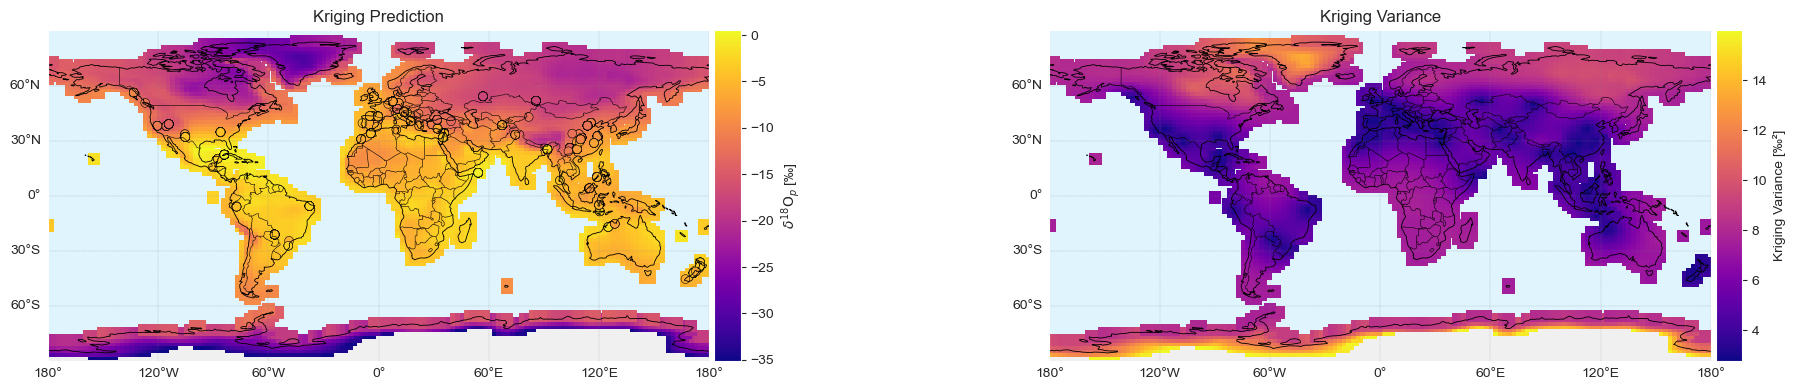

In [3]:
###### SETUP ######
qty='d18Op_VSMOW_linearized'
res_months=200*12
# vario_path = f'{utils.get_project_root()}/output/variograms/itrace/sim12kyrBP/res2400/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_ele_D/sisal_mask/variogram_params_None.json'
vario_path = '../output/variograms/2026-02-24_sisal_vs_itrace/itrace/sim12kyrBP/res2400/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/variogram_params_None.json'
temperature_ds_name = 'itrace' # 1) 'itrace' for 20-11 ka BP, or 2) 'krapp' for 0-800ka BP with res 1000 years
temperature_ds_path = '/media/luluxette/T7_Shield/pdm/iTrace/'

itrace_folder = '/media/luluxette/T7_Shield/pdm/iTrace/' # abs path to itrace data 

###### LOAD DATA ######
# SISAL 
data_with_time_slices = geostat_utils.get_sisal_data_for_kriging(
    res=res_months//12,
    temp_ds_name=temperature_ds_name,
    temp_ds_path=temperature_ds_path,
    conversion=qty,
    verbose=False
)

# ITRACE 
itrace_data = geostat_utils.get_preprocessed_itrace_data(data_folder=itrace_folder,res=res_months,verbose=False) # simulation 12k
itrace_times = itrace_data['time'].unique() #type:ignore # thisis the bumber of time steps in itrace df
external_drift_df = itrace_data[itrace_data['time']==itrace_times[-1]].dropna() #type:ignore
external_drift_df['lon'] = utils.convert_lon_0_360_to_neg180_180(np.asarray(external_drift_df['lon'].values))
# plot_utils.plot_global_map(external_drift_df,'external drift','d18Op',unit='‰ VSMOW', lat_col='lat',lon_col='lon') # type:ignore
data_to_krige = data_with_time_slices[ (data_with_time_slices['binned_age']==11200)].copy()
# plot_utils.plot_global_map(data_to_krige,'sISAL data to krige - 11-11.2 kyr BP',unit='‰ VSMOW',quantity_col=qty,lat_col='lat',lon_col='lon') # type:ignore
###### VARIOGRAM ######
with open(vario_path, 'r') as f:
    variogram_dict = json.load(f)
# define variogram model
variogram_model = variogram_dict['model_name'] 
variogram_parameters = {
    "sill": variogram_dict['sill'], 
    "range": variogram_dict['range'],  
    "nugget": variogram_dict['nugget']
}
###### EXT DRIFT AT OBS POINTS ######
# Retrieve itrace **at** observation points
lats_obs = data_to_krige['lat']
lons_obs  = data_to_krige['lon']
# Linear interpolation from itrace grid to observation points
grid_points = np.column_stack((external_drift_df['lat'], external_drift_df['lon']))
obs_points = np.column_stack((lats_obs, lons_obs))
itrace_at_obs = griddata(grid_points, external_drift_df['d18Op'].values, obs_points, method='linear')
# fig,ax = plot_utils.plot_platecarree_field_and_scatter_on_top(external_drift_df,
#                                                               pd.DataFrame({'lat':lats_obs,'lon':lons_obs,'d18Op':itrace_at_obs}),
#                                                               )
# plt.show()
###### PROJECT IN MERCATOR COORDS ######
# Project data in CRS system for kriging 
data_to_krige['x'],data_to_krige['y'] = geostat_utils.project_coords(data_to_krige['lon'].values,data_to_krige['lat'].values)
external_drift_df['x'],external_drift_df['y'] = geostat_utils.project_coords(external_drift_df['lon'].values,external_drift_df['lat'].values)
itrace_values_xygrid = external_drift_df['d18Op'].values
###### KRIGING ######
# universal kriging object
uk = UniversalKriging(
    x=data_to_krige["x"],
    y=data_to_krige["y"],
    z=data_to_krige[qty],
    variogram_model=variogram_model,
    variogram_parameters=variogram_parameters,
    drift_terms=["specified"],
    specified_drift=[itrace_at_obs]
)
# execute 
z_pred, ss_pred = uk.execute(
    style="points",
    xpoints=external_drift_df['x'],
    ypoints=external_drift_df['y'],
    specified_drift_arrays=[itrace_values_xygrid]
)
# gather results in df
df_pred = pd.DataFrame({'lon': external_drift_df['lon'],
            'lat':external_drift_df['lat'],
            'z_pred':z_pred,
            'ss_pred':ss_pred})
# mask predictions according to a kriging variance threshold
df_pred_masked = df_pred[df_pred['ss_pred']<15]
###### PLOTTING ######
fig,axes = plot_utils.plot_ked_platecarree_points(
    df_pred=df_pred_masked,
    df_obs=data_to_krige,               
    value_col=qty,
    cmap='plasma',
    s_pred=80,
    figsize=(20,4),
    adjust_extent=False
) # type:ignore
plt.tight_layout()
# plt.savefig('../output/ked_firsttests/test_fig.png',dpi=500)
plt.show()

#### Kriging validation metrics analysis 

In this section, we read and plot the cross-validation metrics obtained when running the script ```kriging.py```.

In [3]:
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
res = 200
list_crossval_df = []
list_crossval_metrics = [] 
for kyr in sims.keys() :
    for time in range((int(kyr)-1)*1000+res,int(kyr)*1000+1,res):
        fp_output = f"{utils.get_project_root()}/output/kriging/runs_wip/run_2026_04-15_amount_weighted_drift/res{res}/plots_and_metrics/{str(int(time))}yrBP/" #run_2026_03_05_all_varios
        crossval_df = pd.read_csv(f'{fp_output}crossval_df.csv').reset_index(drop=True)
        crossval_df['time']=time
        with open(fp_output+'crossval_metrics.json', 'r') as f: 
            crossval_metrics = json.load(f)
        list_crossval_df.append(crossval_df)
        list_crossval_metrics.append(pd.DataFrame(crossval_metrics,index=[time]))

crossval_df = pd.concat(list_crossval_df)
crossval_metrics = pd.concat(list_crossval_metrics)

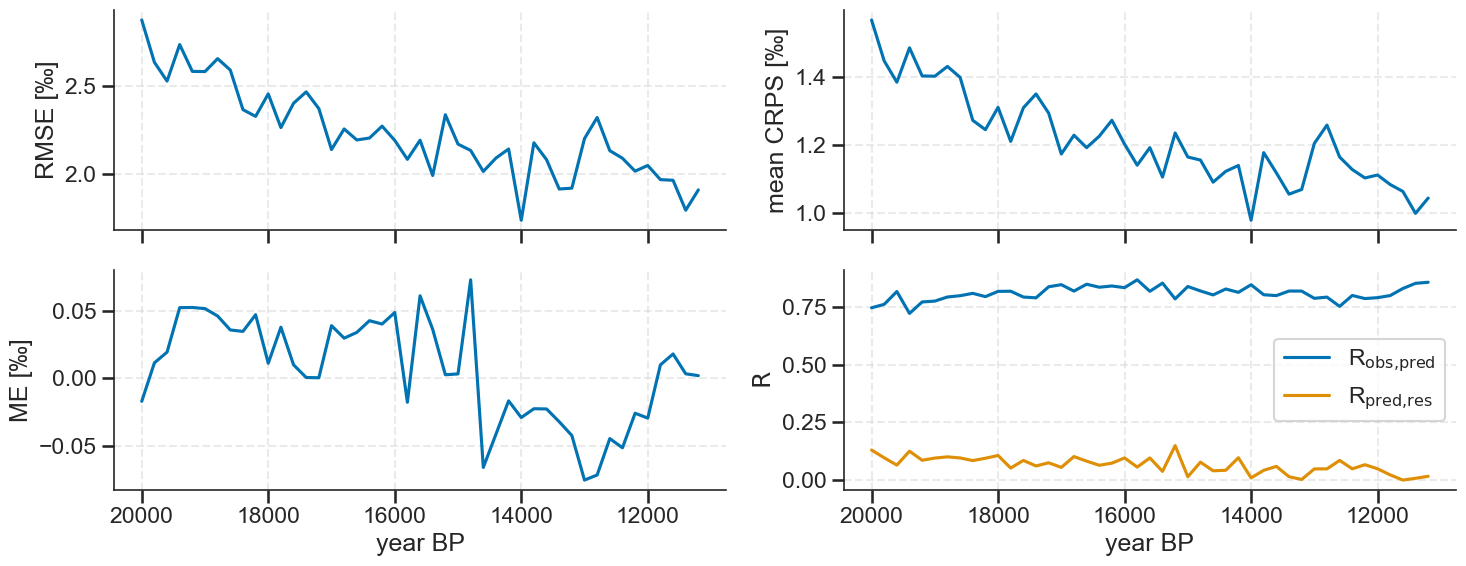

In [3]:
fig, axes = plt.subplots(2,2,figsize=(15,6),sharex='col')

# Scatter plot of irregular points
# axes[0].plot(crossval_metrics.index.values,crossval_metrics['MAE'])
axes[0,0].plot(crossval_metrics.index.values,crossval_metrics['RMSE'])
axes[0,0].set_ylabel('RMSE [‰]')
axes[1,0].plot(crossval_metrics.index.values,crossval_metrics['ME'])
axes[1,0].set_ylabel('ME [‰]')
axes[0,1].plot(crossval_metrics.index.values,crossval_metrics['mean CRPS'])
axes[0,1].set_ylabel('mean CRPS [‰]')
# rejected_slices = crossval_df.loc[crossval_df['|PES| > critical_val'],'time'].unique()
# axes[1,1].scatter(crossval_metrics[crossval_metrics.index.isin(rejected_slices)].index.values,np.ones(len(crossval_metrics[crossval_metrics.index.isin(rejected_slices)]))*0, marker='s', color='tab:orange',label=r'$H_0$ rejected')
# axes[1,1].scatter(crossval_metrics[~crossval_metrics.index.isin(rejected_slices)].index.values,np.ones(len(crossval_metrics[~crossval_metrics.index.isin(rejected_slices)]))*0, marker='s', color='darkcyan',label=r'$H_0$ not rejected')
# axes[1,1].plot(crossval_
# metrics.index.values,np.array([len(crossval_df[crossval_df.time==t]) for t in crossval_metrics.index.values]))
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_obs_pred'],label=r'R$_\text{obs,pred}$')
axes[1,1].plot(crossval_metrics.index.values,crossval_metrics['R_pred_res'],label=r'R$_\text{pred,res}$')
axes[1,1].set_ylabel(r'$\text{R}$')
axes[1,1].legend()
axes[1,1].set_xlabel('year BP')
axes[1,0].set_xlabel('year BP')
axes[0,0].grid(alpha=0.4)
axes[1,0].grid(alpha=0.4)
axes[0,1].grid(alpha=0.4)
axes[1,1].grid(alpha=0.4)
sns.despine(top=True,right=True)
axes[1,0].invert_xaxis()
axes[1,1].invert_xaxis()
plt.tight_layout()
plt.savefig('../output/essd_figs/fig7.png',dpi=300) #_noDevilsHole_noPacupahhuain
plt.show()

In [4]:
crossval_metrics['RMSE'].mean() #-crossval_metrics['mean CRPS'].min()

np.float64(2.233469670593228)

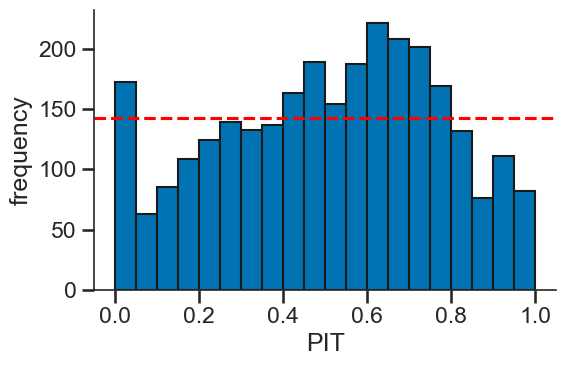

Skewness of PIT distribution: -0.2113881682386994


In [3]:
import scipy.stats as stats

# PIT = Phi((z_obs – z_pred) / sigma) with sigma = sqrt(variance)
sigma = np.sqrt(crossval_df['ss_pred'].values)
pit_vals = stats.norm.cdf((crossval_df['z_obs'].values-crossval_df['z_pred'].values)/sigma)
# obs - pred : underestimation>0, overestimation<0
crossval_df['PIT'] = pit_vals
n=20
plt.figure(figsize=(6,4))
plt.hist(pit_vals[~np.isnan(pit_vals)], bins=n, edgecolor='k')
plt.axhline(len(pit_vals)/n, color='red', linestyle='--')
plt.xlabel('PIT')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout()
# plt.savefig('../output/results_figs/PIT_histogram_agg_vario_noCriticalSites.png',dpi=500)
plt.show()

# compute skewness of PIT distribution
from scipy.stats import skew
skewness = skew(pit_vals[~np.isnan(pit_vals)])
print(f'Skewness of PIT distribution: {skewness}')
# we interpret a skewness value close to 0 as an indication of a well-calibrated model,
# while significant positive or negative skewness may suggest systematic biases in the predictions.
# In our case, a skewness of 0.26 suggests a slight bias towards underprediction (strong right tail),
# but it's not a strong deviation from 0, indicating that the model is reasonably well-calibrated.

In [6]:
crossval_df[crossval_df['PIT']<0.01]

,Unnamed: 0,site_name,lon,lat,z_pred,ss_pred,z_obs,drift_at_obs,dist_nn,residual,PES,|PES| > critical_val,ci,time,PIT
14,14,Devils Hole,-116.2915,36.4254,-11.209153,3.615601,-17.469812,-11.943807,174.634382,6.260659,-3.292531,True,6.200263,11200,0.000496
15,15,Devils Hole,-116.2915,36.4254,-10.916540,3.539500,-17.817538,-11.796754,174.634382,6.900998,-3.668098,True,6.091335,11600,0.000122
14,14,Devils Hole,-116.2915,36.4254,-12.205350,3.664050,-18.125392,-11.836234,174.634382,5.920042,-3.092745,False,6.210573,12000,0.000992
29,29,Hölloch im Mahdtal,10.1506,47.3781,-9.481212,3.802141,-14.420765,-11.818589,344.639810,4.939553,-2.533224,False,6.326523,12000,0.005651
26,26,Hölloch im Mahdtal,10.1506,47.3781,-9.593417,4.627653,-15.148955,-12.606328,346.343290,5.555539,-2.582532,False,6.950028,12200,0.004904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,37,Sieben Hengste cave,7.8100,46.7500,-9.377233,7.189726,-15.615415,-10.585151,561.429230,6.238182,-2.326494,False,8.219415,19800,0.009996
10,10,Devils Hole,-116.2915,36.4254,-13.603373,5.106850,-19.116182,-12.117182,87.226347,5.512808,-2.439475,False,6.996692,20000,0.007354
31,31,Pacupahuain cave,-75.8200,-11.2400,-9.727021,7.580046,-17.361342,-9.850733,612.441323,7.634322,-2.772902,False,8.524170,20000,0.002778
41,41,Sieben Hengste cave,7.8100,46.7500,-9.089070,8.279846,-15.818561,-10.572332,1027.652451,6.729491,-2.338681,False,8.908967,20000,0.009676


In [7]:
crossval_df.PIT.median()

0.5353384712775615

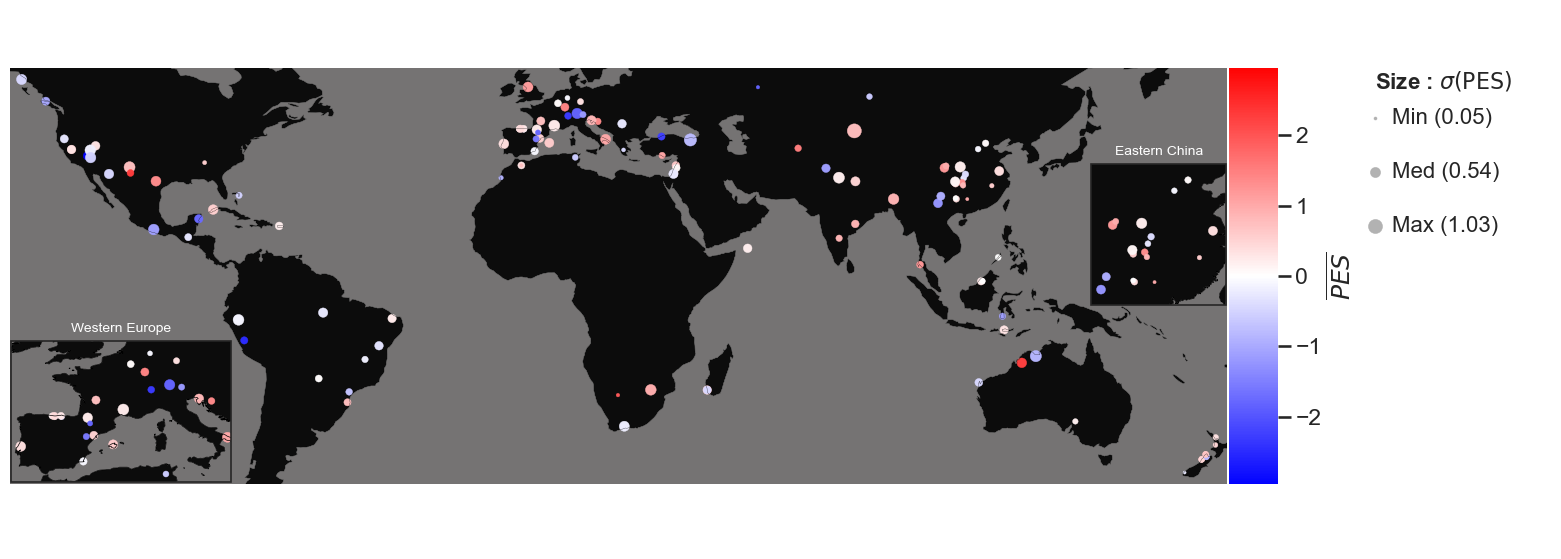

In [30]:
# map of metrics per site
def plot_metric_meanstd_per_site(crossval_df, qty_col,qty_label, cmap, cmap_sym0=False, unit='‰'):
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.geoaxes import GeoAxes
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    grp = crossval_df.groupby('site_name')
    df1 = pd.DataFrame({
        'lat': grp['lat'].first(),
        'lon': grp['lon'].first(),
        qty_col: grp[qty_col].mean(),
        f'{qty_col}_100std': (grp[qty_col].std()*100)
    }).reset_index()
    
    fig1,ax1= plot_utils.plot_isoscape_latlon_platecarree_df(
        df=df1,
        figsize=(14,7),
        title=None,
        qty_col=qty_col,
        size_col=f'{qty_col}_100std',
        cmap=cmap,
        unit=unit,
        countries_borders=False,
        cmap_sym0=cmap_sym0,
        qty_label=rf'$\overline{{{qty_label}}}$',
        landcolor="#0C0C0C",
        oceancolor="#757373",
        marker='o',
        ) # type:ignore
    
    vmin = df1[qty_col].min() if not cmap_sym0 else min(df1[qty_col].min(),-df1[qty_col].max())
    vmax = df1[qty_col].max() if not cmap_sym0 else max(df1[qty_col].max(),-df1[qty_col].min())
    
    # Add insets for zoomed regions
    # Western Europe inset in Pacific Ocean
    axins_eu = inset_axes(ax1, width="34%", height="34%", loc='center left',
                         bbox_to_anchor=(-0.088, -0.325, 1, 1), bbox_transform=ax1.transAxes,
                         axes_class=GeoAxes, axes_kwargs=dict(projection=ccrs.PlateCarree()))
    axins_eu.set_extent([-10, 18, 35, 53], crs=ccrs.PlateCarree())
    
    # Plot data in Western Europe inset
    sc_eu = axins_eu.scatter(
        df1['lon'],
        df1['lat'],
        c=df1[qty_col],
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        s=df1[f'{qty_col}_100std'],
        edgecolor=None,
        linewidths=0.3,
        alpha=0.99,
        vmin=vmin,
        vmax=vmax,
        marker='o'
    )
    axins_eu.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axins_eu.add_feature(cfeature.LAND, facecolor="#0C0C0C", edgecolor="none")
    axins_eu.add_feature(cfeature.OCEAN, facecolor="#757373", edgecolor="none")
    axins_eu.set_title('Western Europe', fontsize=10,color='white')
    
    # Eastern China inset in Indian Ocean
    axins_china = inset_axes(ax1, width="34%", height="34%", loc='center right',
                            bbox_to_anchor=(0.123, 0.1, 1, 1), bbox_transform=ax1.transAxes,
                            axes_class=GeoAxes, axes_kwargs=dict(projection=ccrs.PlateCarree()))
    axins_china.set_extent([102, 121, 22, 42], crs=ccrs.PlateCarree())
    
    # Plot data in Eastern China inset
    sc_china = axins_china.scatter(
        df1['lon'],
        df1['lat'],
        c=df1[qty_col],
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        s=df1[f'{qty_col}_100std'],
        edgecolor=None,
        linewidths=0.3,
        alpha=0.99,
        vmin=vmin,
        vmax=vmax,
        marker='o'
    )
    axins_china.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axins_china.add_feature(cfeature.LAND, facecolor="#0C0C0C", edgecolor="none")
    axins_china.add_feature(cfeature.OCEAN, facecolor="#757373", edgecolor="none")
    axins_china.set_title('Eastern China', fontsize=10,color='white')
    
    return (fig1,ax1)

(fig1,ax1) = plot_metric_meanstd_per_site(crossval_df,'PES','PES','bwr',cmap_sym0=True,unit=None) # type:ignore
plt.tight_layout()
# plt.savefig('../output/essd_figs/fig8.png',dpi=300,bbox_inches='tight') 
plt.show()

Is the PES correlated to the altitude of the caves ? 

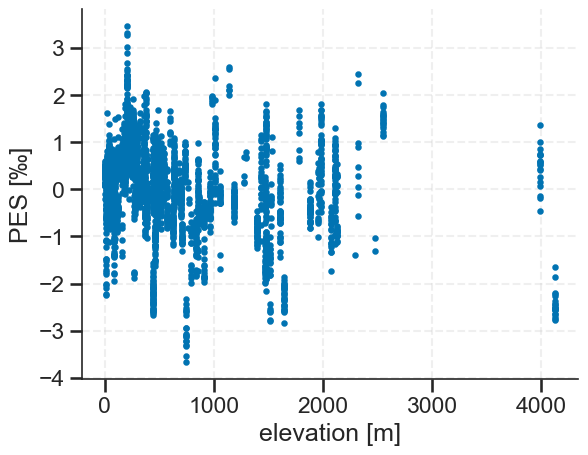

In [ ]:
from geostat_isoscapes_tools.geostat_utils import add_external_variables_to_lonlat_df

crossval_df = add_external_variables_to_lonlat_df(crossval_df,variables=['ele'])


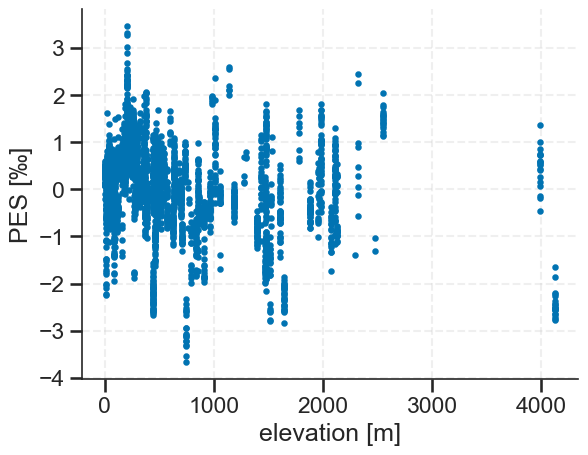

In [31]:
plt.scatter(crossval_df['ele'],crossval_df['PES'],marker='o',s=10)
plt.xlabel('elevation [m]')
plt.ylabel('PES [‰]')
sns.despine()
plt.grid()
plt.show()

In [24]:
crossval_df.columns

Index(['Unnamed: 0', 'site_name', 'lon', 'lat', 'z_pred', 'ss_pred', 'z_obs',
       'drift_at_obs', 'dist_nn', 'residual', 'PES', '|PES| > critical_val',
       'ci', 'time', 'ele'],
      dtype='object')

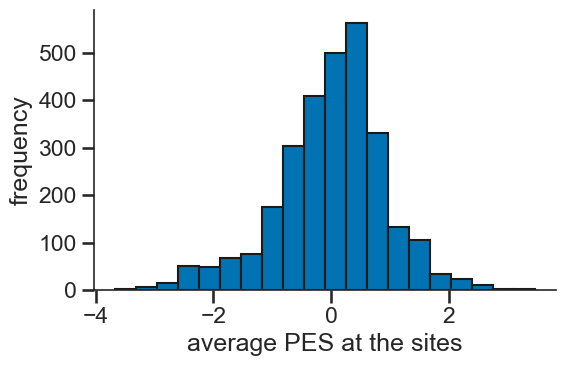

In [12]:
import scipy.stats as stats
# histogram of mean residuals per site 
plt.figure(figsize=(6,4))
plt.hist(crossval_df.PES.values, bins=20, edgecolor='k')
# plt.axhline(len(crossval_df.groupby('site_name')['PIT'].mean().values)/10, color='red', linestyle='--')
# overlay the normal distribution N(0,1)
# x = np.linspace(-3, 3, 100)
# y = stats.norm.pdf(x, loc=0, scale=0.6)
# plt.plot(x, y * len(crossval_df.groupby('site_name')) * 20 / 100, color='red', linewidth=2)
plt.xlabel('average PES at the sites')
plt.ylabel('frequency')
sns.despine()
plt.tight_layout() 
plt.show()

Let us observe the cross-val predictions at some caves versus the observed values, over the whole period.

In [5]:
def plot_pred_obs_at_site_over_time(crossval_df, site_name):
    df_site = crossval_df.loc[crossval_df.site_name==site_name]
    fig,ax=plt.subplots(figsize=(5,4))
    plt.plot(df_site.time.values,df_site['z_pred'].values,'--+',linewidth=1.,markersize=6,label='pred')
    plt.plot(df_site.time.values,df_site['z_obs'].values,'--.',linewidth=1.,markersize=6,label='obs')
    plt.plot(df_site.time.values,df_site['drift_at_obs'].values,'--x',linewidth=1.,markersize=6,label='drift')
    plt.xlabel('Time [yr BP]')
    sns.despine()
    ax.invert_xaxis()
    plt.legend(frameon=False)
    plt.ylabel(r'$\delta^{18}\text{O}$ [‰]')
    plt.title(site_name)
    return fig,ax


      site_name       lon      lat       PES
27  Devils Hole -116.2915  36.4254 -2.957514


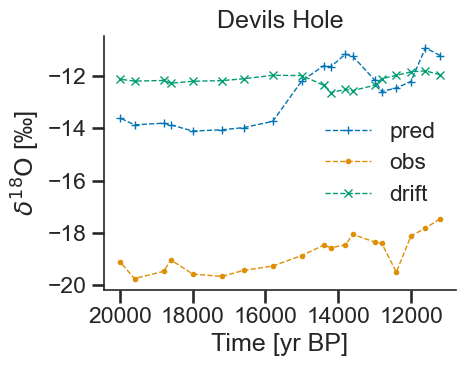

            site_name    lon   lat       PES
97  Pink Panther cave -105.2  32.0  2.256022


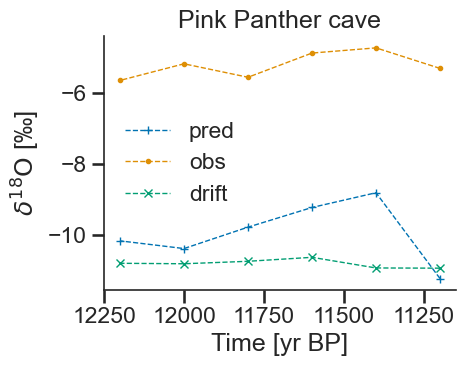

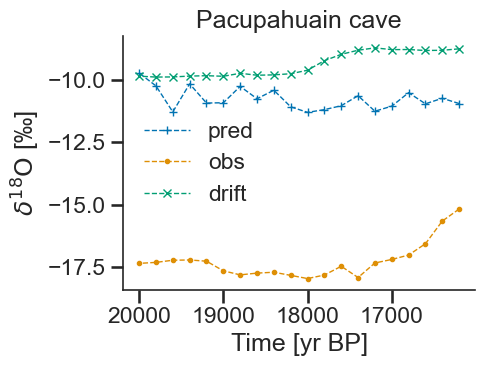

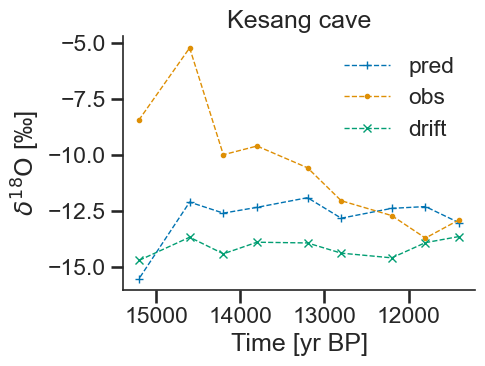

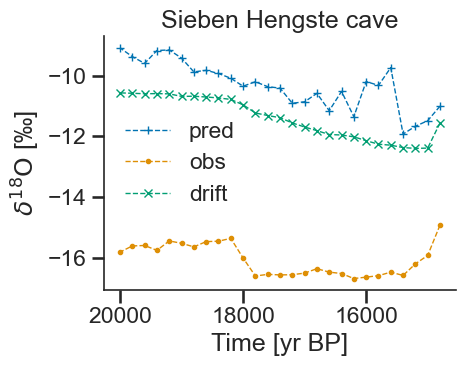

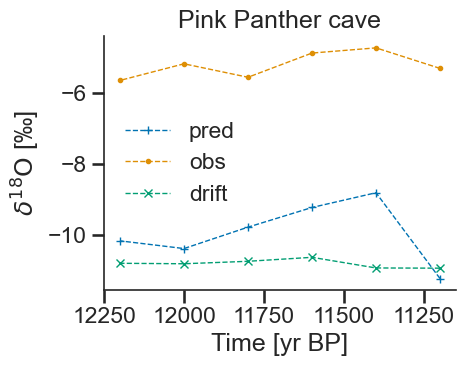

In [50]:
# explore the sites with the bad PES mean values :
mean_pes = crossval_df.groupby('site_name')[['lon','lat','PES']].mean().reset_index()
print(mean_pes[mean_pes.PES == mean_pes.PES.min()])
min_cave = mean_pes.loc[mean_pes.PES.idxmin(),'site_name']
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,min_cave)
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_DevilsHole.png',dpi=500)
plt.show()

#max
print(mean_pes[mean_pes.PES == mean_pes.PES.max()])
max_cave = mean_pes.loc[mean_pes.PES.idxmax(),'site_name']
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,max_cave)
plt.tight_layout()
plt.show()

#Pacupahuain cave
fig, ax = plot_pred_obs_at_site_over_time(crossval_df,'Pacupahuain cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Pacupahuain.png',dpi=500)
plt.show()

# Kesang cave 
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Kesang cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_Kesang.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Sieben Hengste cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_SiebenHengste.png',dpi=500)
plt.show()

# Sieben Hengste cave
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,'Pink Panther cave')
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

##### Sites where the CV results are the best

summary : 
 - 4,51 "Bukit Assam cave", "Lianhua cave, Shanxi" : KED corrected the bias but the temporal patterns are still out of sync
 - 5 Buraca Gloriosa : Bias was greatly reduced but the iTraCE drift has smoothed temporal patterns, uncorrected.
 - 9,64,70,120 Creighton's cave, Palawan cave, Ruakuri cave, Mairs cave : bias greatly reduced -9 to -4 and -7.3 -5 and -8 to -5
 - 10,11,65,130 : Cueva Victoria, de Asiul, Pere Noel cave, Twin Forks cave : drift and obs were very correlated but bias was large : now largely corrected 
 - 12 : Bias in the other way (iTraCE overestimated d18O) greatly reduced + temporal pattern improvement
 - 16,22,63,83,93,100,114 : ?,Furong cave, Ostolo cave, Wazpretti cave, Hollywood cave, Pindal cave,Wet Neck cave : patterns match very well, bias midly reduced 
 - 20,35,37,48,58,123,126 : El Condor cave, KNI-51, Karaca cave, Leviathan cave, Moaning cave, cave C126, Pinnacle cave : strange behaviour in terms of temporal continuity !
 - 21,27,31,42,44,87 : El Soplao cave, Haozhu cave, Jaraguá cave, La Garma cave, La Vallina, Yamen cave : perfect CV result --> very close to another cave ?
 - 40,46,124 : Kulishu cave, Lapa sem fim cave, Larga cave : drift = obs - bias and less intense patterns --> all corrected, nice result (look at neighbourghs)?
 - Secret cave 75 : 8km to a neighbour...

In [29]:
crossval_df.loc[crossval_df.site_name.isin([
    'El Soplao cave', 
    'Haozhu cave', 
    'Jaraguá cave',
    'La Garma cave', 
    'La Vallina', 
    'Yamen cave',
    'Kulishu cave', 
    'Lapa sem fim cave', 
    'Larga cave'
    ]),['site_name','dist_nn']].groupby('site_name').min()

,dist_nn
site_name,
El Soplao cave,15.958929
Haozhu cave,117.461764
Jaraguá cave,891.629786
Kulishu cave,237.235562
La Garma cave,13.739668
La Vallina,22.380770
Lapa sem fim cave,552.591183
Larga cave,1380.880978
Yamen cave,28.873176


Haozhu cave


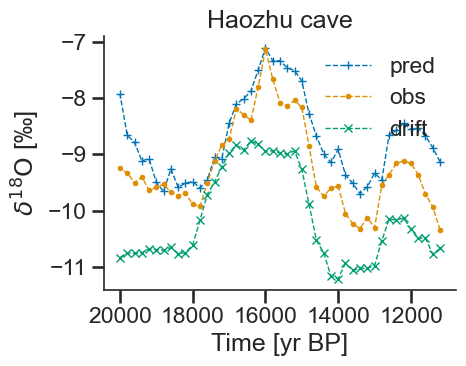

Kulishu cave


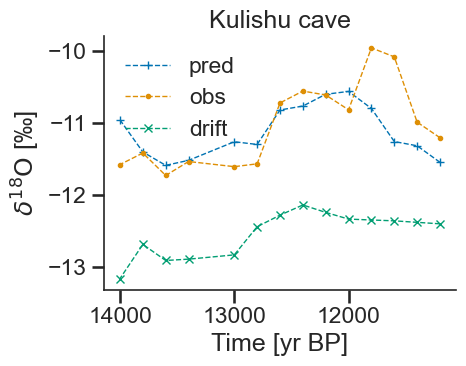

Lapa sem fim cave


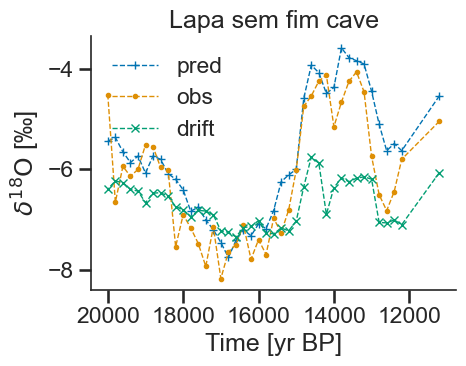

Jaraguá cave


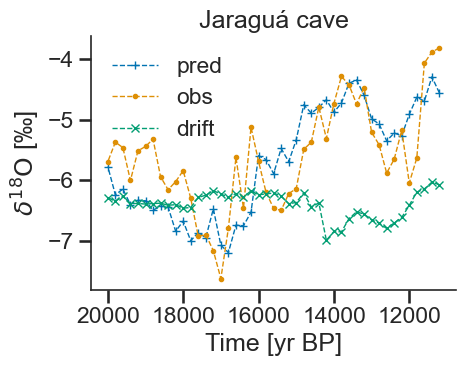

Larga cave


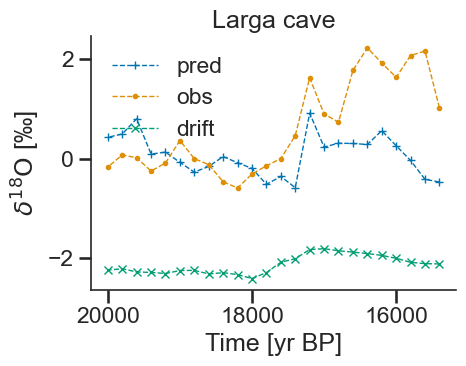

In [36]:
num = 27
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 40
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 46
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num =31
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

num = 124
print(crossval_df.site_name.unique()[num])
fig,ax = plot_pred_obs_at_site_over_time(crossval_df,crossval_df.site_name.unique()[num]) 
plt.tight_layout()
# plt.savefig('../output/results_figs/obs_pred_drift_PinkPantherCave.png',dpi=500)
plt.show()

#### Statistical test results 
In the cel below, we investigate whether the statistical was failed in some time slices, and because of which sites.

In [120]:
crossval_df.loc[crossval_df['|PES| > critical_val'],['site_name','dist_nn','z_obs','z_pred','ss_pred','PES','time','lat','lon']]

,site_name,dist_nn,z_obs,z_pred,ss_pred,PES,time,lat,lon
14,Devils Hole,174.634382,-17.469812,-11.209153,3.615601,-3.292531,11200,36.4254,-116.2915
15,Devils Hole,174.634382,-17.817538,-10.916540,3.539500,-3.668098,11600,36.4254,-116.2915
13,Devils Hole,174.634382,-19.506681,-12.451238,3.969029,-3.541459,12400,36.4254,-116.2915
14,Devils Hole,408.576801,-18.465962,-11.157772,4.854530,-3.316929,13800,36.4254,-116.2915
11,Devils Hole,408.576801,-18.569032,-11.634069,4.667872,-3.209850,14200,36.4254,-116.2915
13,Devils Hole,408.576801,-18.476414,-11.602208,4.594169,-3.207149,14400,36.4254,-116.2915
1,Ball Gown cave,431.804831,0.761203,-7.069790,5.723275,3.273366,14800,-17.0300,125.0000
1,Ball Gown cave,431.804831,1.000173,-6.994891,5.800877,3.319519,15000,-17.0300,125.0000
2,Ball Gown cave,431.804831,1.010895,-6.789369,5.087278,3.458331,15200,-17.0300,125.0000


#### Vizualise kriged dataset

In this section, we open the dataset .nc file that was created by running the script ```kriging.py``` and we plot some isoscapes.

In [26]:
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/runs_wip/run_2026_04-15_amount_weighted_drift/res200/speleothems_isoscapes_11_to_20kaBP.nc')

In [27]:
d18Op = kriged_ds.d18Op
d18Op_var = kriged_ds.ss_pred
confidence_flags = kriged_ds.confidence_flag

In [28]:
kriged_ds.time

<xarray.DataArray 'time' (time: 45)> Size: 360B
array([11200., 11400., 11600., 11800., 12000., 12200., 12400., 12600., 12800.,
       13000., 13200., 13400., 13600., 13800., 14000., 14200., 14400., 14600.,
       14800., 15000., 15200., 15400., 15600., 15800., 16000., 16200., 16400.,
       16600., 16800., 17000., 17200., 17400., 17600., 17800., 18000., 18200.,
       18400., 18600., 18800., 19000., 19200., 19400., 19600., 19800., 20000.])
Coordinates:
  * time     (time) float64 360B 1.12e+04 1.14e+04 1.16e+04 ... 1.98e+04 2e+04
Attributes:
    units:        years
    description:  Years before Present (1950). Positive integers.

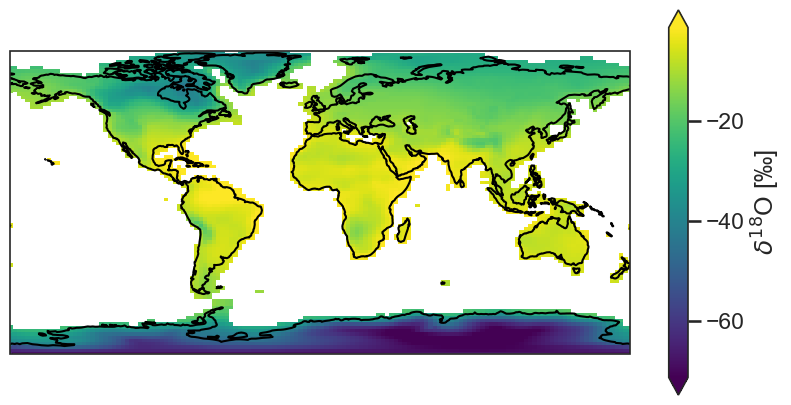

In [29]:
fig = plot_utils.plot_isoscape_latlon_platecarree(d18Op.sel(time=19200),time='',title='')
plt.show()

In [30]:
kriged_df = kriged_ds.to_dataframe().reset_index().dropna()

In [31]:
kriged_df.columns

Index(['time', 'lat', 'lon', 'd18Op', 'ss_pred', 'confidence_flag'], dtype='object')

In [32]:
kriged_df['std']=np.sqrt(kriged_df.ss_pred)

In [ ]:
# Compare to itrace values

# load itrace siulations dict 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sims = dict((k,itrace_sims[k]) for k in ('12', # early holocene
                                         '13',
                                         '14',
                                         '15', # HS1
                                         '16',
                                         '17',
                                         '18',
                                         '19',
                                         '20' # last millenial of LGM
                                         ) if k in itrace_sims)

df_list = []

for kyr,dict_ in sims.items() :
    print(f'=== {kyr} ka BP ===')
    itrace_df  = geostat_utils.get_preprocessed_itrace_data(
            true_kyr=int(float(kyr)),
            res=200, # 200 years times 12 months
            data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
            format='df',
            amount_weighted=True,
            verbose=False,
            sim_suffix =dict_['suffix'], 
            sim_forcings=dict_['forcings'],
            sim_kyr= int(dict_['yrBPname']),
            sim_num=dict_['num'],
            sim_model='clm2.h0',
        ) # df
    if any(itrace_df.lon > 180): itrace_df['lon'] =  utils.convert_lon_0_360_to_neg180_180(itrace_df.lon.values) #type:ignore
    
    # keep only the 200-year slice at the beginning of this 1000 years slice 
    # itrace_slice = itrace_df[(itrace_df.time == float(kyr)*1000)].copy() #type:ignore #&(itrace_df.lat.between(-55,70))
    # kriged_slice = kriged_df[(kriged_df.time == float(kyr)*1000)].copy() 

    # truncate both datasets to filter out the locations where we have no confidence in the kriging predictions (sigma>3)
    # kriged_slice = kriged_slice[kriged_slice['confidence_flag']==1].copy()
    # itrace is defined on the same grid so we can exactly keep the same locations as in the kriged slice
    # itrace_slice = itrace_slice[itrace_slice.set_index(['lat','lon']).index.isin(kriged_slice.set_index(['lat','lon']).index)]

    # # set a single colorbar for both next plots 
    # vmin = min(min(itrace_slice.d18Op),min(kriged_slice.d18Op))
    # vmax = max(max(itrace_slice.d18Op),max(kriged_slice.d18Op))
    # print(vmin,vmax)
    # fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
    #             df=kriged_slice,
    #             title=None,
    #             v_min=vmin,
    #             v_max=vmax,
    #             cmap='plasma',
    #             qty_label=r'Kriged $\delta^{18}$O$_p$',
    #             countries_borders=True) #type:ignore
    # plt.tight_layout()
    # # plt.savefig(f'../output/results_figs/kriged_isoscape_{kyr}_kaBP.png',dpi=500)
    # plt.show()
    # # fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
    #             df=kriged_slice,
    #             title=None,
    #             qty_col = 'std',
    #             # v_min=vmin,
    #             # v_max=vmax,
    #             cmap='plasma',
    #             qty_label=r'$\sigma_\text{KED}$',
    #             unit=r'‰',
    #             countries_borders=True) #type:ignore
    # plt.tight_layout()
    # # plt.savefig(f'../output/results_figs/kriged_isoscape_std_{kyr}_kaBP.png',dpi=500)
    # plt.show()
    # fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
    #     itrace_slice,#type:ignore
    #     v_min=vmin,
    #     v_max=vmax,
    #     cmap='plasma',
    #     qty_label=r'iTraCE $\delta^{18}$O$_p$',
    #     title=None,
    #     countries_borders=True
    # )
    # plt.tight_layout()
    # # plt.savefig(f'../output/results_figs/itrace_isoscape_{kyr}_kaBP.png',dpi=500)
    # plt.show()

    # compute the difference at each location 
    itrace_slice = itrace_df.rename(columns={'d18Op':'itrace_d18Op'}) # type:ignore
    # kriged_slice = kriged_df.rename(columns= {'d18Op':'kriged_d18Op'})

    # merged_df = pd.merge(left=kriged_slice[['lat','lon','kriged_d18Op']],right=itrace_slice[['lat','lon','itrace_d18Op']],how='outer',on=['lat','lon','time']) #type:ignore

    # merged_df['diff'] = (merged_df.kriged_d18Op - merged_df.itrace_d18Op)/np.abs(merged_df.itrace_d18Op)
    # merged_df.dropna(subset='diff')

    df_list.append(itrace_slice)
    # fig,ax = plot_utils.plot_isoscape_latlon_platecarree_df(
    #     merged_df,#type:ignore
    #     qty_col='diff',
    #     qty_label=r'$\delta_\text{norm}$',
    #     cmap='coolwarm',
    #     cmap_sym0=True,
    #     title=None,
    #     unit=None,
    #     countries_borders=True
    # )
    # plt.tight_layout()
    # plt.savefig(f'../output/results_figs/kriged_isoscape_norm_diff_{kyr}_kaBP.png',dpi=500)
    # plt.show()

print('here')
kriged_df = kriged_df.rename(columns= {'d18Op':'kriged_d18Op'})
itrace_df_all = pd.concat(df_list)
merged_df = pd.merge(left=kriged_df[['lat','lon','kriged_d18Op','time']],right=itrace_df_all[['lat','lon','itrace_d18Op','time']],how='outer',on=['lat','lon','time']) #type:ignore
merged_df['diff'] = (merged_df.kriged_d18Op - merged_df.itrace_d18Op)/np.abs(merged_df.itrace_d18Op)
merged_df.dropna(subset='diff')


=== 12 ka BP ===
=== 13 ka BP ===
=== 14 ka BP ===
=== 15 ka BP ===
=== 16 ka BP ===
=== 17 ka BP ===
=== 18 ka BP ===
=== 19 ka BP ===
=== 20 ka BP ===
here


,lat,lon,kriged_d18Op,time,itrace_d18Op,diff
0,-90.000000,-180.0,-54.839812,11200.0,-46.850983,-0.170516
1,-90.000000,-180.0,-54.162412,11400.0,-46.721836,-0.159253
2,-90.000000,-180.0,-50.024557,11600.0,-46.251877,-0.081568
3,-90.000000,-180.0,-49.657118,11800.0,-46.307129,-0.072343
4,-90.000000,-180.0,-44.311420,12000.0,-46.412991,0.045280
...,...,...,...,...,...,...
281895,84.315788,-20.0,-33.935856,19200.0,-28.487804,-0.191242
281896,84.315788,-20.0,-33.672426,19400.0,-28.294294,-0.190078
281897,84.315788,-20.0,-36.476379,19600.0,-28.322535,-0.287892
281898,84.315788,-20.0,-34.447492,19800.0,-28.404684,-0.212740


In [2]:
merged_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/merged_df_kriged_itrace.csv')

In [5]:
mean_merged_df = merged_df.groupby(['lon', 'lat'],as_index=False).mean()

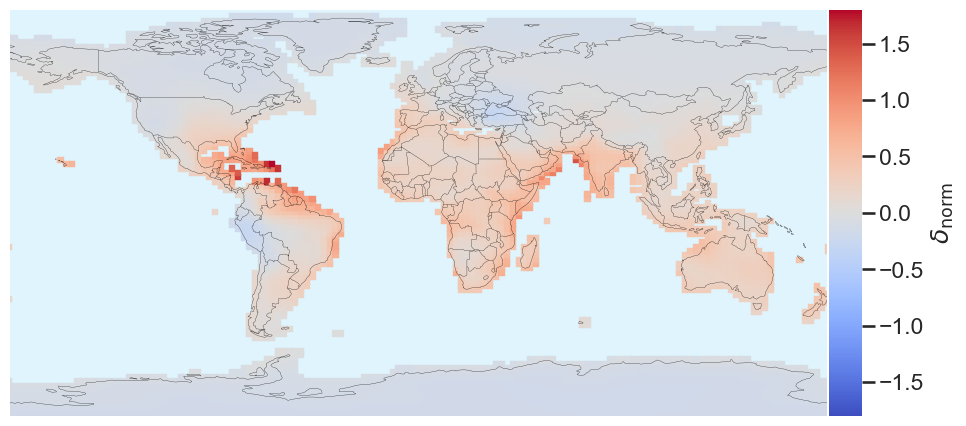

In [15]:
plot_utils.plot_isoscape_latlon_platecarree_df(
    mean_merged_df,#mean_merged_df.lon.between(-100,-63))& (mean_merged_df.lat.between(12,31))],
    qty_col='diff',
    qty_label=r'$\delta_\text{norm}$',
    cmap='coolwarm',
    # s=120,
    cmap_sym0=True,
    title=None,
    unit=None,
    countries_borders=True
)
plt.tight_layout()
plt.savefig('../output/kriged_isoscape_norm_diff_all_times.png',dpi=500)
plt.show()

In [ ]:
#plot the time series of the kriged_d18Op, itrace_d18Op and crossval_df['z_obs'] at the caves in the caribbean region


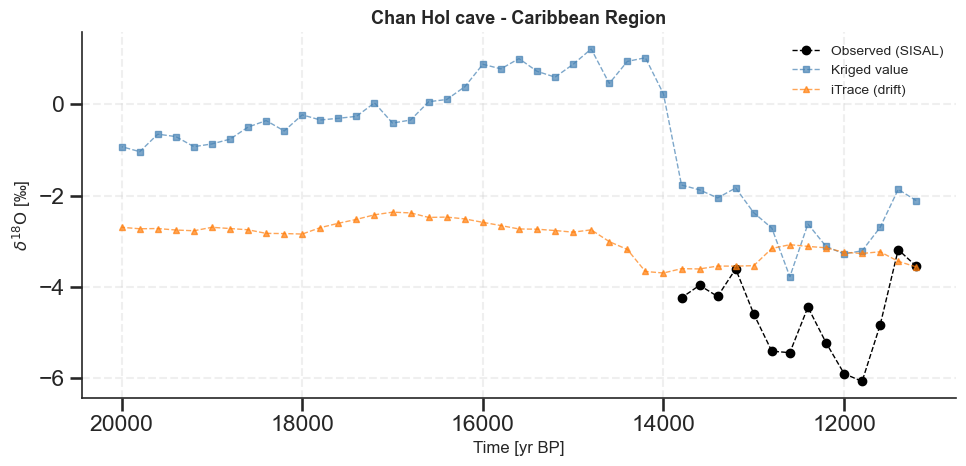

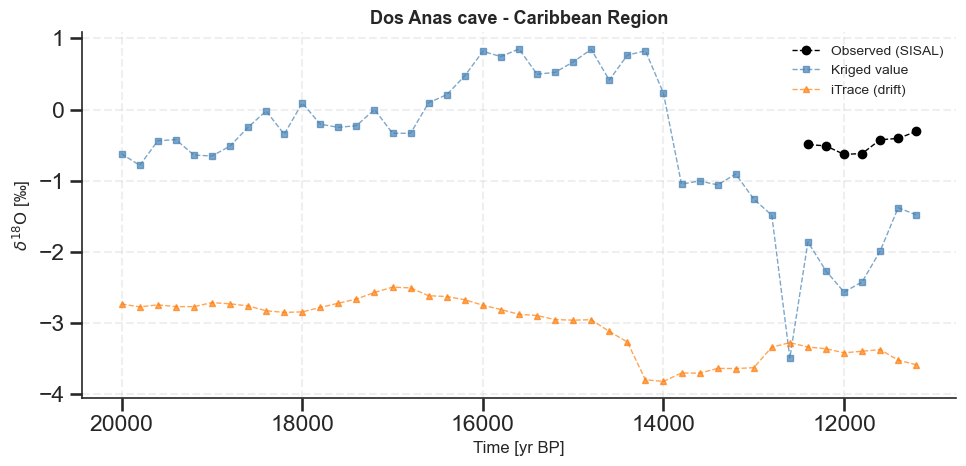

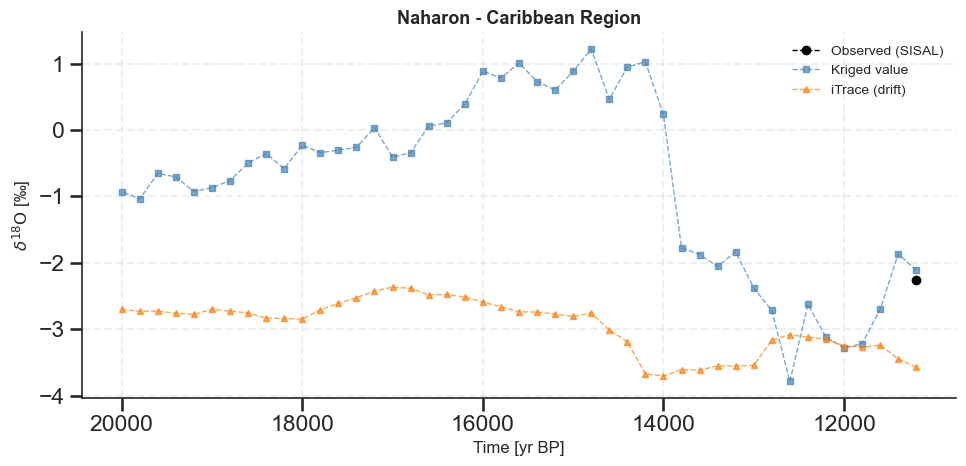

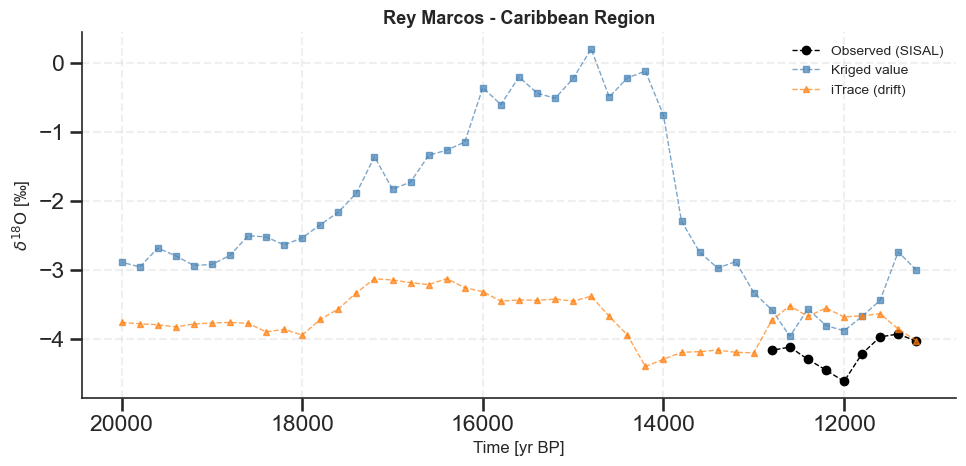

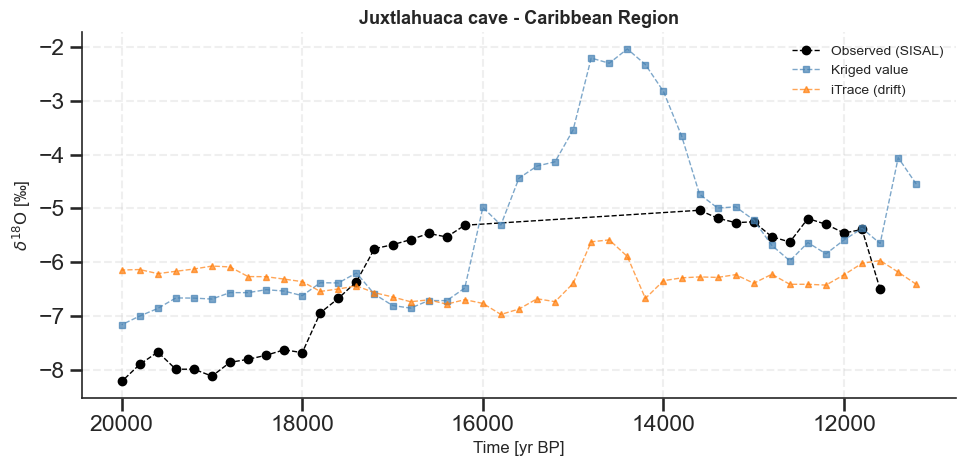

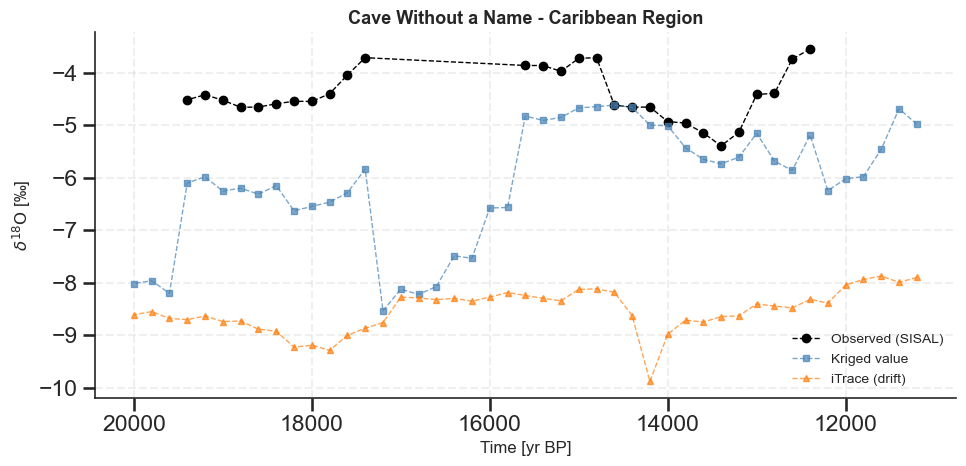

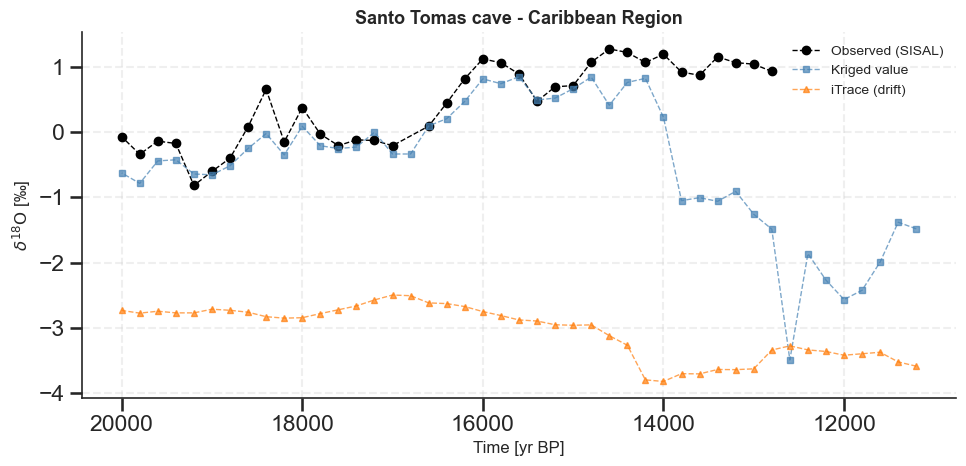

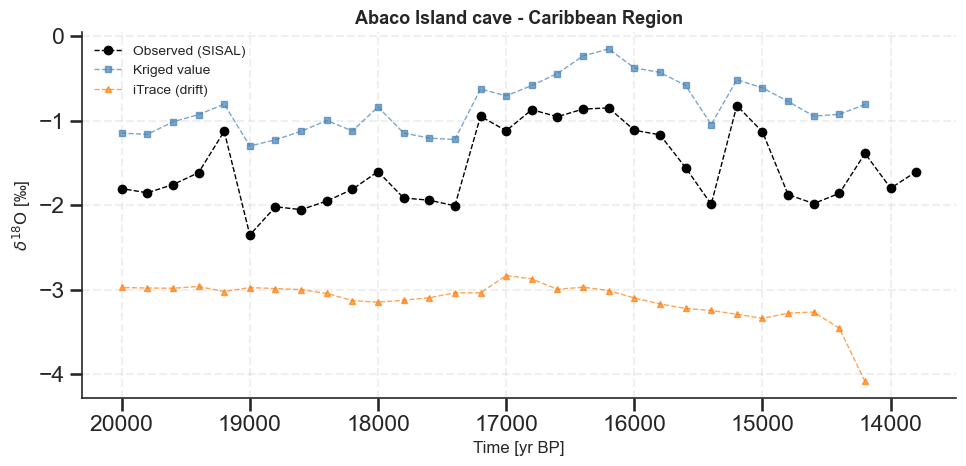

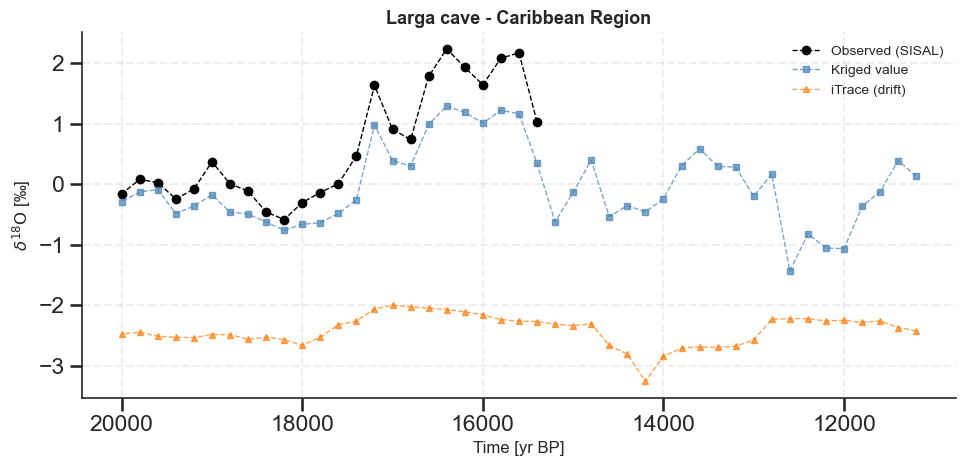

In [38]:
# Filter caves in the Caribbean region
caribbean_caves = crossval_df.loc[
    (crossval_df['lat'].between(12, 31)) & 
    (crossval_df['lon'].between(-100, -63)), 
    'site_name'
].unique()

# Plot time series for each Caribbean cave
for cave_name in caribbean_caves:
    # Get data for this cave
    cave_crossval = crossval_df[crossval_df['site_name'] == cave_name].sort_values('time')

    # Find closest gridpoint to this cave location
    cave_lat = cave_crossval['lat'].iloc[0]
    cave_lon = cave_crossval['lon'].iloc[0]
    
    # Calculate distances to all gridpoints in merged_df
    distances = np.sqrt(
        (merged_df['lat'] - cave_lat)**2 + 
        (merged_df['lon'] - cave_lon)**2
    )
    
    # Find closest gridpoint(s)
    closest_idx = distances.idxmin()
    
    # Get all time steps at the closest location
    drift_and_pred = merged_df[
        (merged_df['lat'] == merged_df.loc[closest_idx, 'lat']) & 
        (merged_df['lon'] == merged_df.loc[closest_idx, 'lon'])
    ].sort_values('time')

    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot observed values from crossval
    ax.plot(cave_crossval['time'], cave_crossval['z_obs'], '--o', 
            linewidth=1, markersize=6, label='Observed (SISAL)', color='black')
    
    # Plot kriged predictions
    ax.plot(drift_and_pred['time'], drift_and_pred['kriged_d18Op'], '--s', 
            linewidth=1, markersize=5, label='Kriged value', color='steelblue', alpha=0.7)
    
    # Plot iTrace values if available
    ax.plot(drift_and_pred['time'], drift_and_pred['itrace_d18Op'], '--^', 
            linewidth=1, markersize=5, label='iTrace (drift)', color='tab:orange', alpha=0.7)
    
    ax.set_xlabel('Time [yr BP]', fontsize=12)
    ax.set_ylabel(r'$\delta^{18}\text{O}$ [‰]', fontsize=12)
    ax.set_title(f'{cave_name} - Caribbean Region', fontsize=13, fontweight='bold')
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=10)
    sns.despine()
    plt.tight_layout()
    plt.show()
